# Pipeline 8 - Full Manga Translation Pipeline Test

Testing the refactored pipeline with:
- `BubbleSegmentationWithOrdering` (panel-aware bubble ordering + visualization)
- `MangaOCRModel`
- `ElanMtJaEnTranslator`
- `MangaTypesetter`
- `MangaPipeline`


In [1]:
import os
import sys

ENDWITHS = 'Pipelines'
NOTEBOOK_DIR = os.getcwd()

if not NOTEBOOK_DIR.endswith(ENDWITHS):
    raise ValueError(f"Not in correct dir, expect end with {ENDWITHS}, but got {NOTEBOOK_DIR} instead")

BASE_DIR = os.path.join(NOTEBOOK_DIR, '..', '..', '..')
sys.path.insert(0, BASE_DIR)
print(f"Base dir: {BASE_DIR}")


Base dir: /Volumes/HP_P900/Users/tungnguyen/Library/CloudStorage/GoogleDrive-nguyenlamtungthptltt@gmail.com/My Drive/Projects-Large/Group-Project-B3/code-just-to-preview/group-project-b3/src/pipeline/Pipelines/../../..


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Pipeline components
from src.pipeline.SegmentationModels.YoloSeg import YoloBubbleSeg, YoloPanelSeg
from src.pipeline.SegmentationModels.BubbleSegmenterWithSplit import BubbleSegmenterWithSplit
from src.pipeline.SegmentationModels.BubbleSegmentationWithOrdering import BubbleSegmentationWithOrdering
from src.pipeline.OCRModels.MangaOCRModel import MangaOCRModel
from src.pipeline.TranslationModels.ElanMtJaEnTranslator import ElanMtJaEnTranslator
from src.pipeline.Utils.MangaTypesetter import MangaTypesetter
from src.pipeline.Utils.MangaPipeline import MangaPipeline

print("Imports successful!")


In [ ]:
# Configuration
DEVICE = "mps"  # Change to "cuda" or "cpu" as needed

# Example image path
EX_IMG_PATH = os.path.join(BASE_DIR, "data/Manga109_released_2023_12_07/images/AisazuNihaIrarenai/007.jpg")

print(f"Device: {DEVICE}")
print(f"Image path: {EX_IMG_PATH}")
print(f"Image exists: {os.path.exists(EX_IMG_PATH)}")


Device: mps
Image path: /Volumes/HP_P900/Users/tungnguyen/Library/CloudStorage/GoogleDrive-nguyenlamtungthptltt@gmail.com/My Drive/Projects-Large/Group-Project-B3/code-just-to-preview/group-project-b3/src/pipeline/Pipelines/../../../data/Manga109_released_2023_12_07/images/AisazuNihaIrarenai/007.jpg
Image exists: True


## 1. Load Image


Image shape: (1170, 1654, 3)


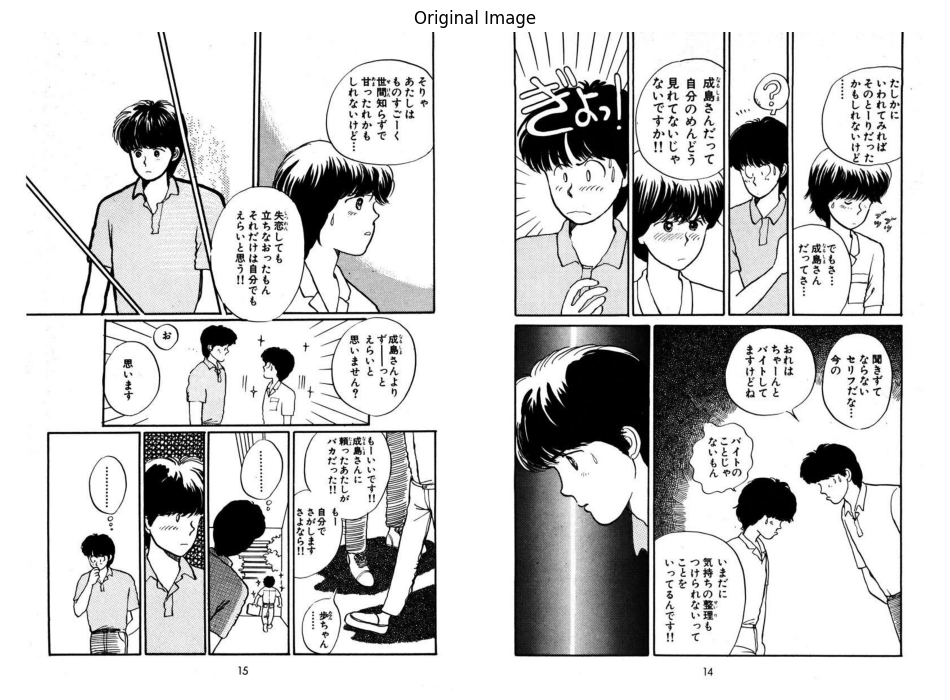

In [ ]:
# Load image
image = cv2.imread(EX_IMG_PATH)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Image shape: {image.shape}")

# Display original image
plt.figure(figsize=(12, 16))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()


## 2. Create and Test Segmentation with Ordering


In [ ]:
# Create detectors
print("Creating bubble detector...")
bubble_detector = YoloBubbleSeg(variant="v8n", device=DEVICE, verbose=True)

print("\nCreating panel detector...")
panel_detector = YoloPanelSeg(variant="v8n", device=DEVICE, verbose=True)

bubble_detector_with_split = BubbleSegmenterWithSplit(
    variant="v8n",
    device=DEVICE,
    verbose=True,
    plot=True
)

# Wrap with ordering
print("\nCreating ordered segmenter...")
ordered_segmenter = BubbleSegmentationWithOrdering(
    bubble_detector=bubble_detector_with_split,
    panel_detector=panel_detector,
    num_panel_rows=4,
    right_to_left=True,
    verbose=True,
    plot=True
)

print("Segmenters created!")


Creating bubble detector...

Creating panel detector...

Creating ordered segmenter...
Segmenters created!


Loading segmentation models...
[BubbleSegmenterWithSplit] Model loaded successfully
[YoloPanelSeg] Model loaded successfully
[BubbleSegmentationWithOrdering] Models loaded

Running segmentation...
[BubbleSegmentationWithOrdering] Detected double-page spread, processing separately...
[BubbleSegmentationWithOrdering] Processing right page...

0: 1280x928 8 balloons, 120.8ms
Speed: 6.7ms preprocess, 120.8ms inference, 68.8ms postprocess per image at shape (1, 3, 1280, 928)

0: 320x256 6 frames, 109.5ms
Speed: 1.4ms preprocess, 109.5ms inference, 38.5ms postprocess per image at shape (1, 3, 320, 256)
[BubbleSegmentationWithOrdering] Processing left page...

0: 1280x928 9 balloons, 26.4ms
Speed: 4.1ms preprocess, 26.4ms inference, 50.2ms postprocess per image at shape (1, 3, 1280, 928)

0: 320x256 8 frames, 13.6ms
Speed: 1.1ms preprocess, 13.6ms inference, 28.3ms postprocess per image at shape (1, 3, 320, 256)
[BubbleSegmentationWithOrdering] Combined 8 + 9 = 17 bubbles


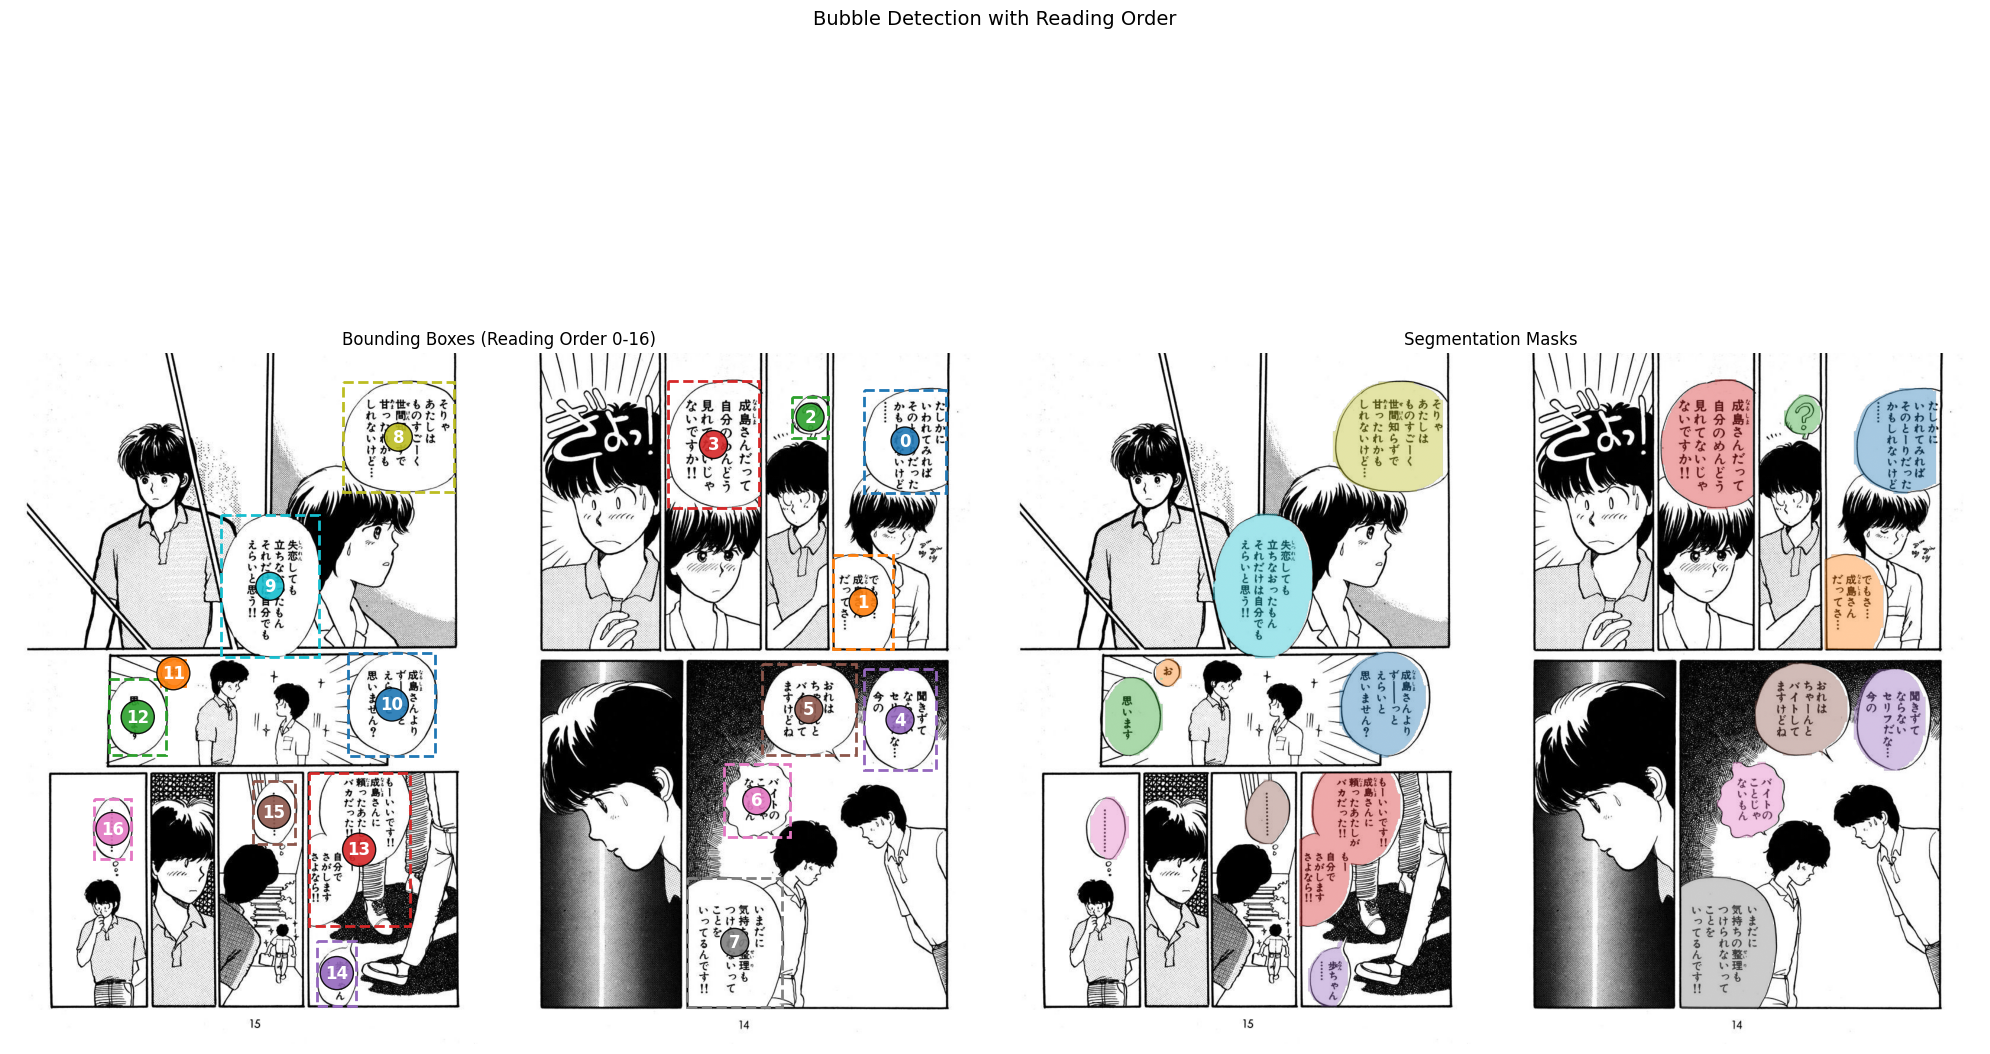

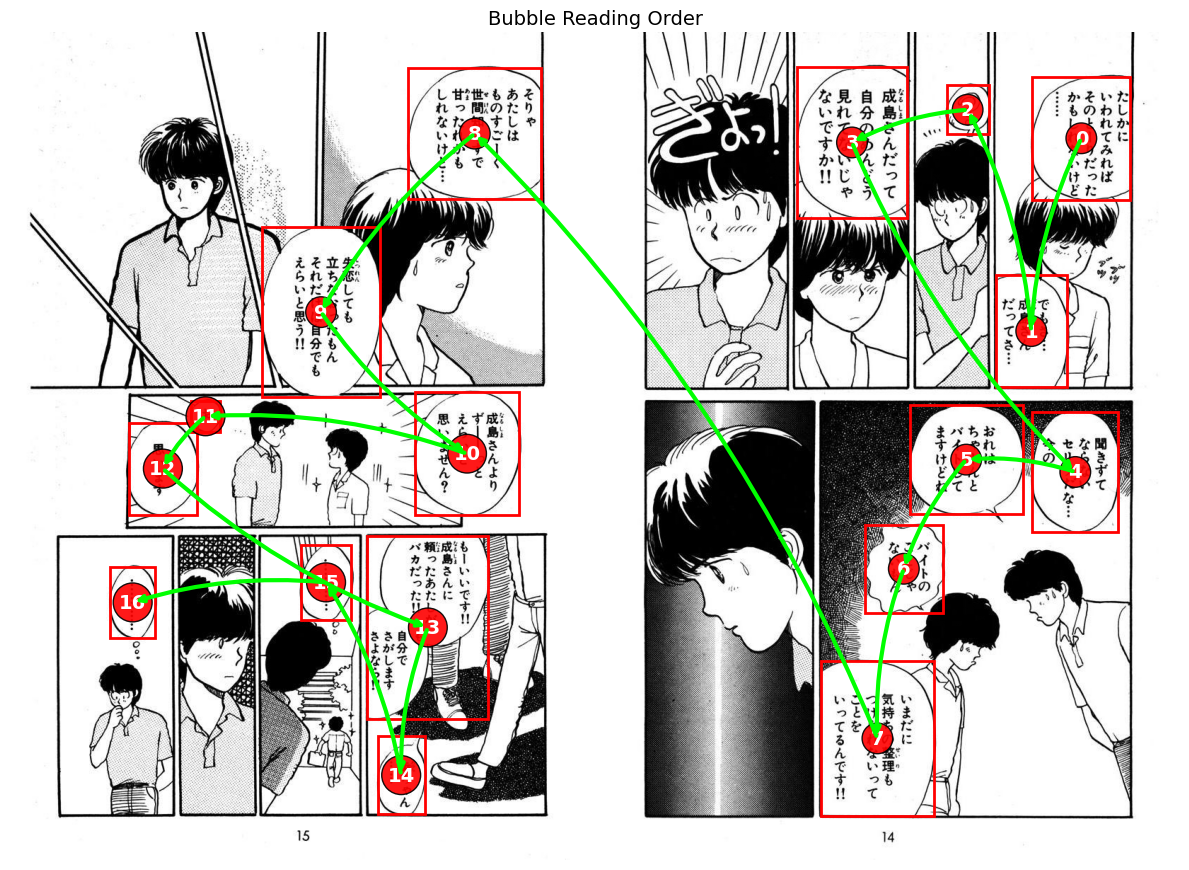

Found 17 bubbles
Confidences: ['0.97', '0.96', '0.84', '0.97', '0.97', '0.97', '0.96', '0.97', '0.98', '0.98', '0.97', '0.91', '0.94', '0.98', '0.94', '0.95', '0.95']


In [ ]:
# Load models and run segmentation
print("Loading segmentation models...")
ordered_segmenter.load_model()

print("\nRunning segmentation...")
bboxes, masks, confs = ordered_segmenter.predict(image, conf_threshold=0.5)

print(f"Found {len(bboxes)} bubbles")
print(f"Confidences: {[f'{c:.2f}' for c in confs]}")


## 3. Visualize Segmentation Results


## 4. Test Full Pipeline


In [ ]:
# Unload segmenter first (will be loaded by pipeline)
ordered_segmenter.unload_model()

# Create full pipeline
print("Creating pipeline components...")
ocr_model = MangaOCRModel(verbose=True)
translator = ElanMtJaEnTranslator(elan_model="tiny", device=DEVICE, verbose=True)
typesetter = MangaTypesetter()

pipeline = MangaPipeline(
    segmenter=ordered_segmenter,
    ocr_model=ocr_model,
    translator=translator,
    typesetter=typesetter,
    verbose=True
)

print("Pipeline created!")


[BubbleSegmenterWithSplit] Model unloaded
[YoloPanelSeg] Model unloaded
[BubbleSegmentationWithOrdering] Models unloaded
Creating pipeline components...
Pipeline created!


2025-12-26 15:40:21.390 | INFO     | manga_ocr.ocr:__init__:16 - Loading OCR model from kha-white/manga-ocr-base


Running full pipeline...

[MangaPipeline] Loading models...
[BubbleSegmenterWithSplit] Model loaded successfully
[YoloPanelSeg] Model loaded successfully
[BubbleSegmentationWithOrdering] Models loaded


2025-12-26 15:40:25.699 | INFO     | manga_ocr.ocr:__init__:25 - Using MPS
2025-12-26 15:40:26.851 | INFO     | manga_ocr.ocr:__init__:35 - OCR ready


[MangaOCRModel] Model loaded successfully


/Volumes/HP_P900/Users/tungnguyen/miniforge3/envs/pip12/lib/python3.12/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use mps


[ElanMtJaEnTranslator] Model loaded successfully
[MangaPipeline] All models loaded
[MangaPipeline] Segmenting bubbles...
[BubbleSegmentationWithOrdering] Detected double-page spread, processing separately...
[BubbleSegmentationWithOrdering] Processing right page...

0: 1280x928 8 balloons, 31.2ms
Speed: 4.0ms preprocess, 31.2ms inference, 15.7ms postprocess per image at shape (1, 3, 1280, 928)

0: 320x256 6 frames, 19.4ms
Speed: 0.6ms preprocess, 19.4ms inference, 10.1ms postprocess per image at shape (1, 3, 320, 256)
[BubbleSegmentationWithOrdering] Processing left page...

0: 1280x928 9 balloons, 22.3ms
Speed: 4.0ms preprocess, 22.3ms inference, 25.2ms postprocess per image at shape (1, 3, 1280, 928)

0: 320x256 8 frames, 13.9ms
Speed: 1.0ms preprocess, 13.9ms inference, 13.2ms postprocess per image at shape (1, 3, 320, 256)
[BubbleSegmentationWithOrdering] Combined 8 + 9 = 17 bubbles


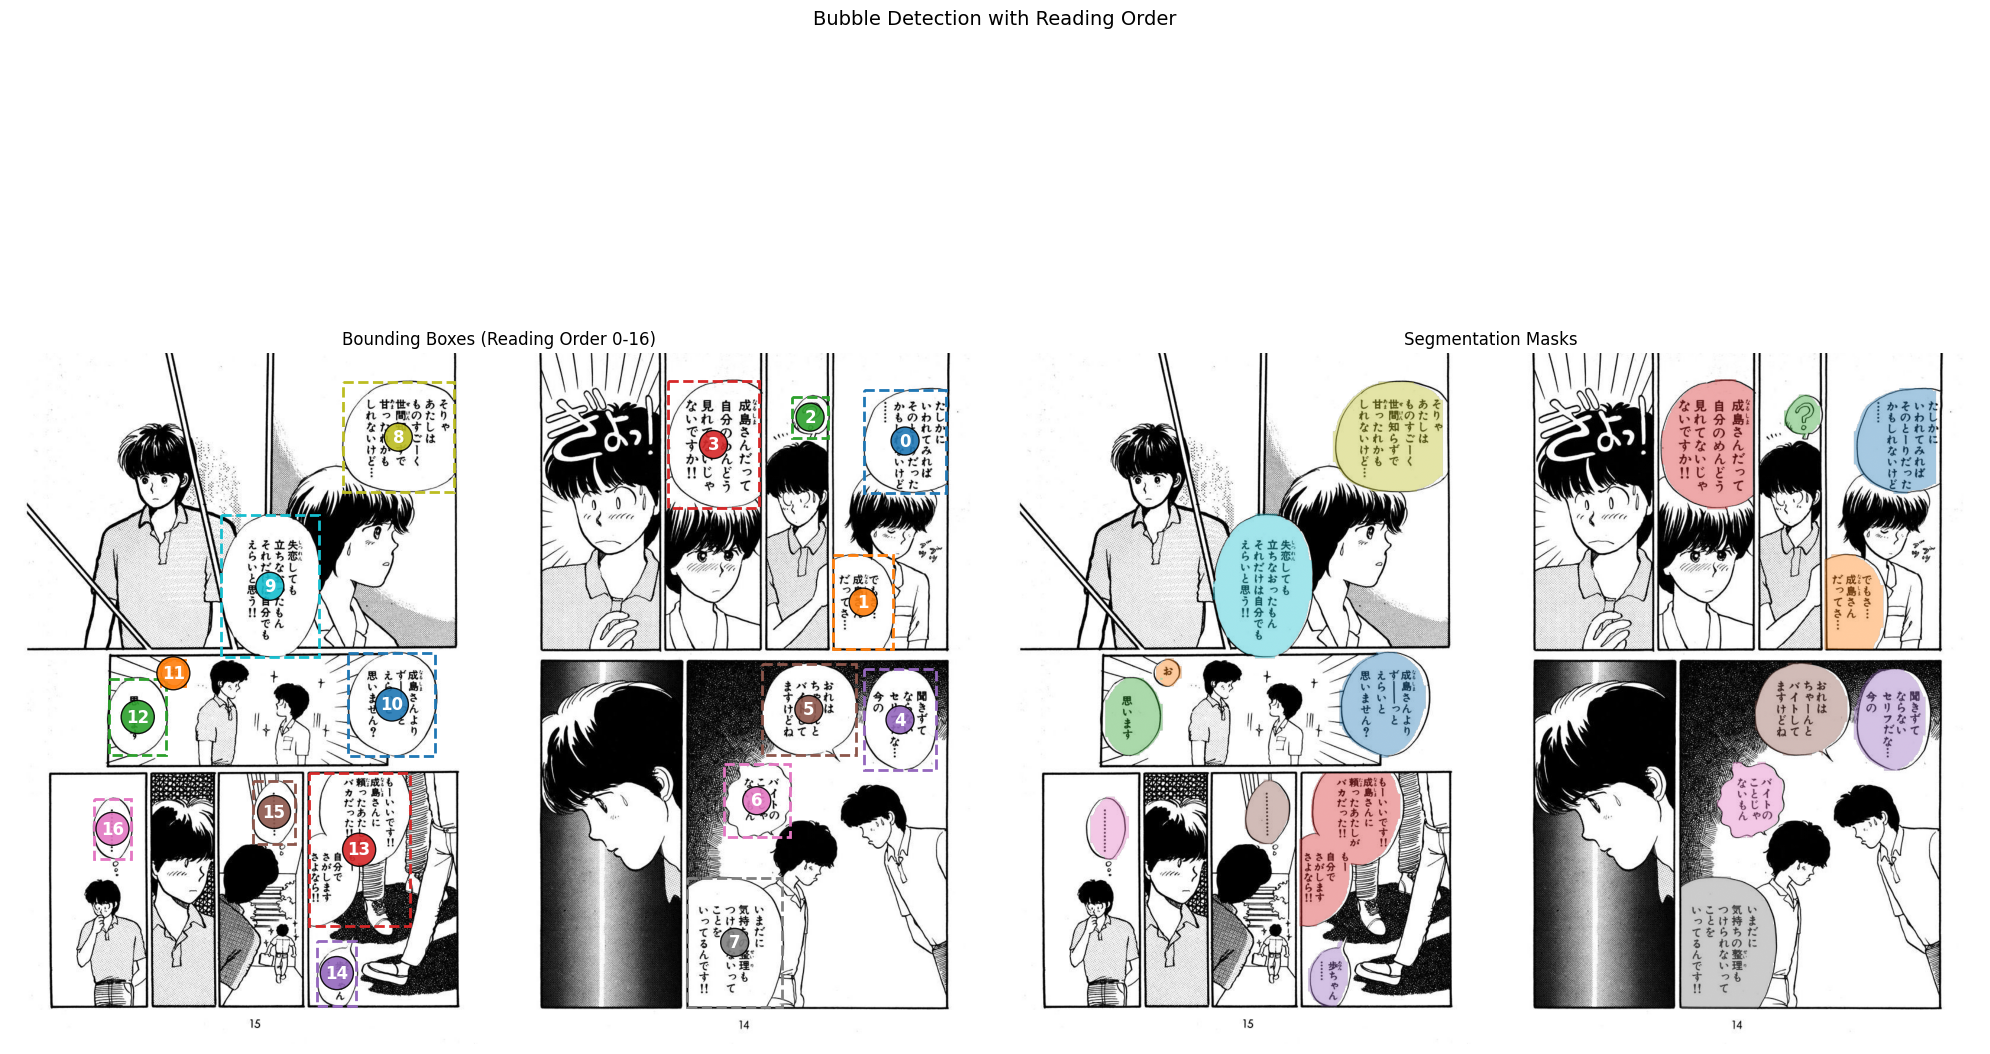

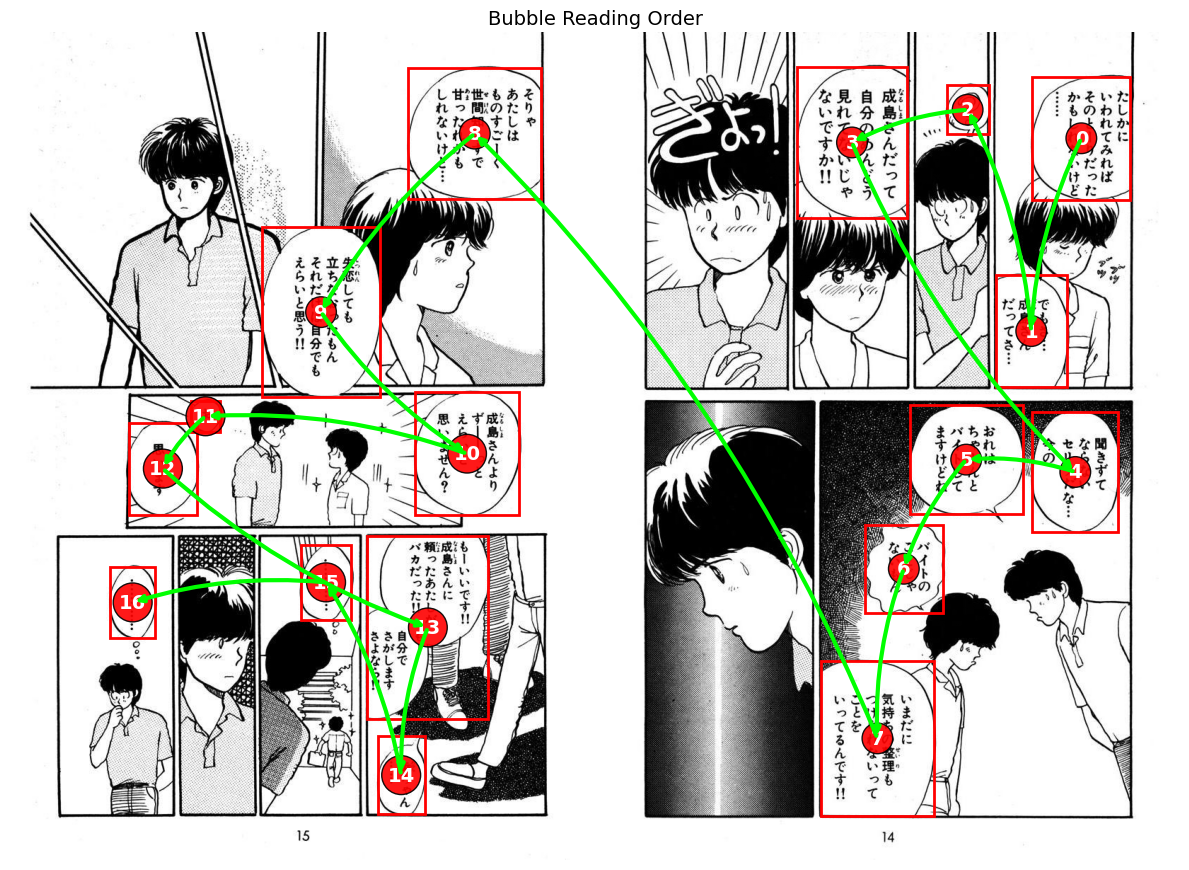

[MangaPipeline] Found 17 bubbles
[MangaPipeline] Running OCR...
[MangaPipeline] OCR complete: 17 texts extracted
[MangaPipeline] Translating...
[MangaPipeline] Translation complete
[MangaPipeline] Rendering text...
[MangaPipeline] Done
[MangaPipeline] Unloading models...
[BubbleSegmenterWithSplit] Model unloaded
[YoloPanelSeg] Model unloaded
[BubbleSegmentationWithOrdering] Models unloaded
[MangaOCRModel] Model unloaded
[ElanMtJaEnTranslator] Model unloaded
[MangaPipeline] All models unloaded
Pipeline completed!


In [ ]:
# Run full pipeline with context manager
print("Running full pipeline...\n")

with pipeline:
    final_image, results = pipeline.process(image, conf_threshold=0.5, return_intermediate=True)

print("Pipeline completed!")


In [ ]:
# Display OCR and Translation results

print("PIPELINE RESULTS")

if 'ocr_texts' in results:
    print(f"\n📝 OCR Results ({len(results['ocr_texts'])} bubbles):")
    for i, text in enumerate(results['ocr_texts']):
        print(f"  [{i}] {text}")

print(f"\n🌐 Translated Texts:")
for i, text in enumerate(results['translated_texts']):
    print(f"  [{i}] {text}")


PIPELINE RESULTS

📝 OCR Results (17 bubbles):
  [0] たしかにいわれてみればそのとーりだったかもしれないけど．．．
  [1] でもさ．．．成島さんだってさ．．．
  [2] っ．．．
  [3] 成島さんだって自分のめんどう見れてないじゃないですか！！
  [4] 聞きずてならないセリフだな．．．今の
  [5] おれはちゃーんとバイトしてますけどね
  [6] バイトのことじゃないもん
  [7] いまだに気持ちの整理もつけられないってことをいっでるんです！！
  [8] そりゃあたしはものすごーく世間知らずで甘ったれかもしれないけど．．．
  [9] 失恋しても立ちなおったもんそれだけは自分でもえらいと思う！！
  [10] 成島さんよりずーーっとえらいと思いません？
  [11] お
  [12] 思います
  [13] もーいいです！！成島さんに頼ったあたしがバカだった！！自分でさかしますさよなら！！
  [14] 歩ちゃん．．．
  [15] ．．．．．．
  [16] ．．．

🌐 Translated Texts:
  [0] I could have seen it as if it was a bit of it. ...
  [1] But it's true to Narishima...
  [2] ...
  [3] I don't care what I'm looking for, Narishima!!
  [4] I'm not listening to.
  [5] I have a part-time job.
  [6] It's not a part-time job.
  [7] I still don't have enough feelings for you!
  [8] I'm afraid I'm going to be sweeted by the ignorance of the world. ...
  [9] If you lose your love, you'll be able to get it back to yourself!
  [10] Don't you think that's better than Narishima?
  [11

## 5. Compare Original vs Translated


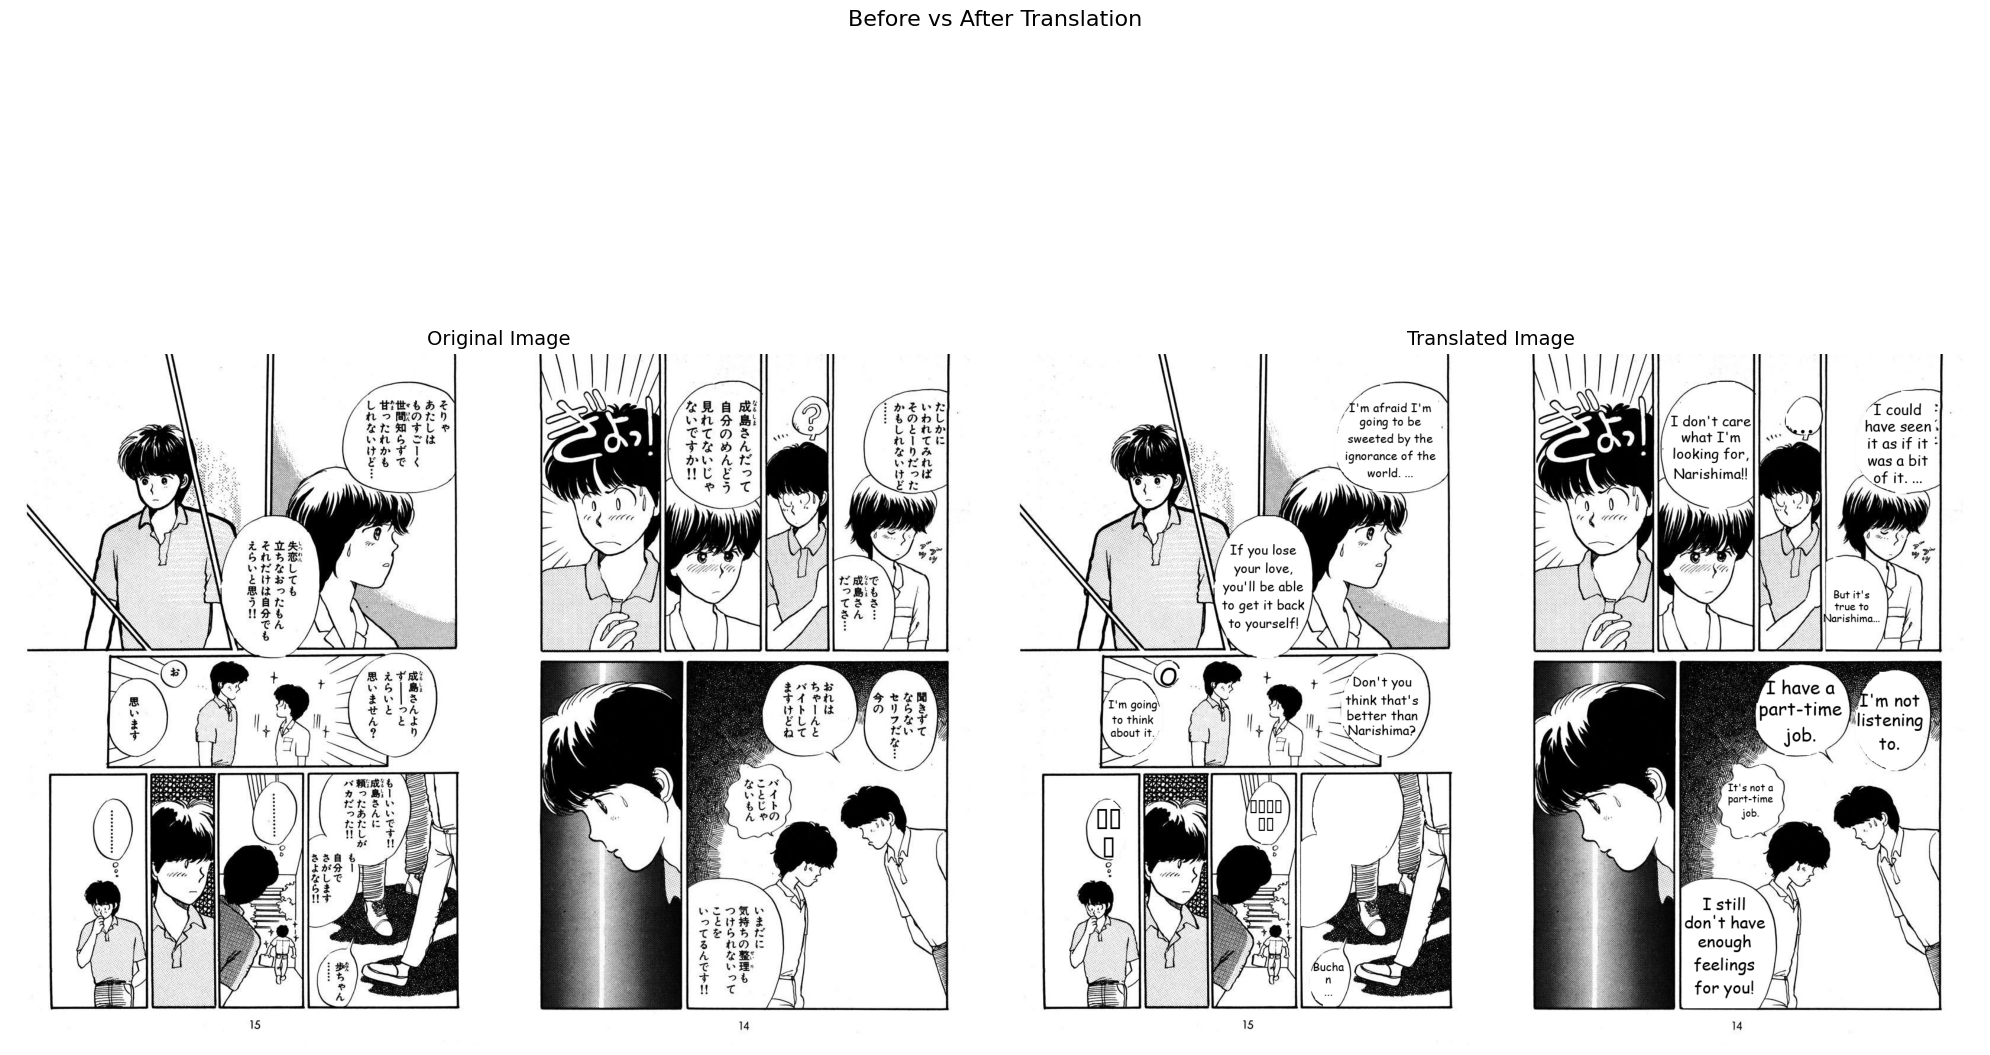

In [ ]:
# Compare original vs final
fig, axes = plt.subplots(1, 2, figsize=(20, 14))

axes[0].imshow(image)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

axes[1].imshow(final_image)
axes[1].set_title("Translated Image", fontsize=14)
axes[1].axis('off')

plt.suptitle("Before vs After Translation", fontsize=16)
plt.tight_layout()
plt.show()


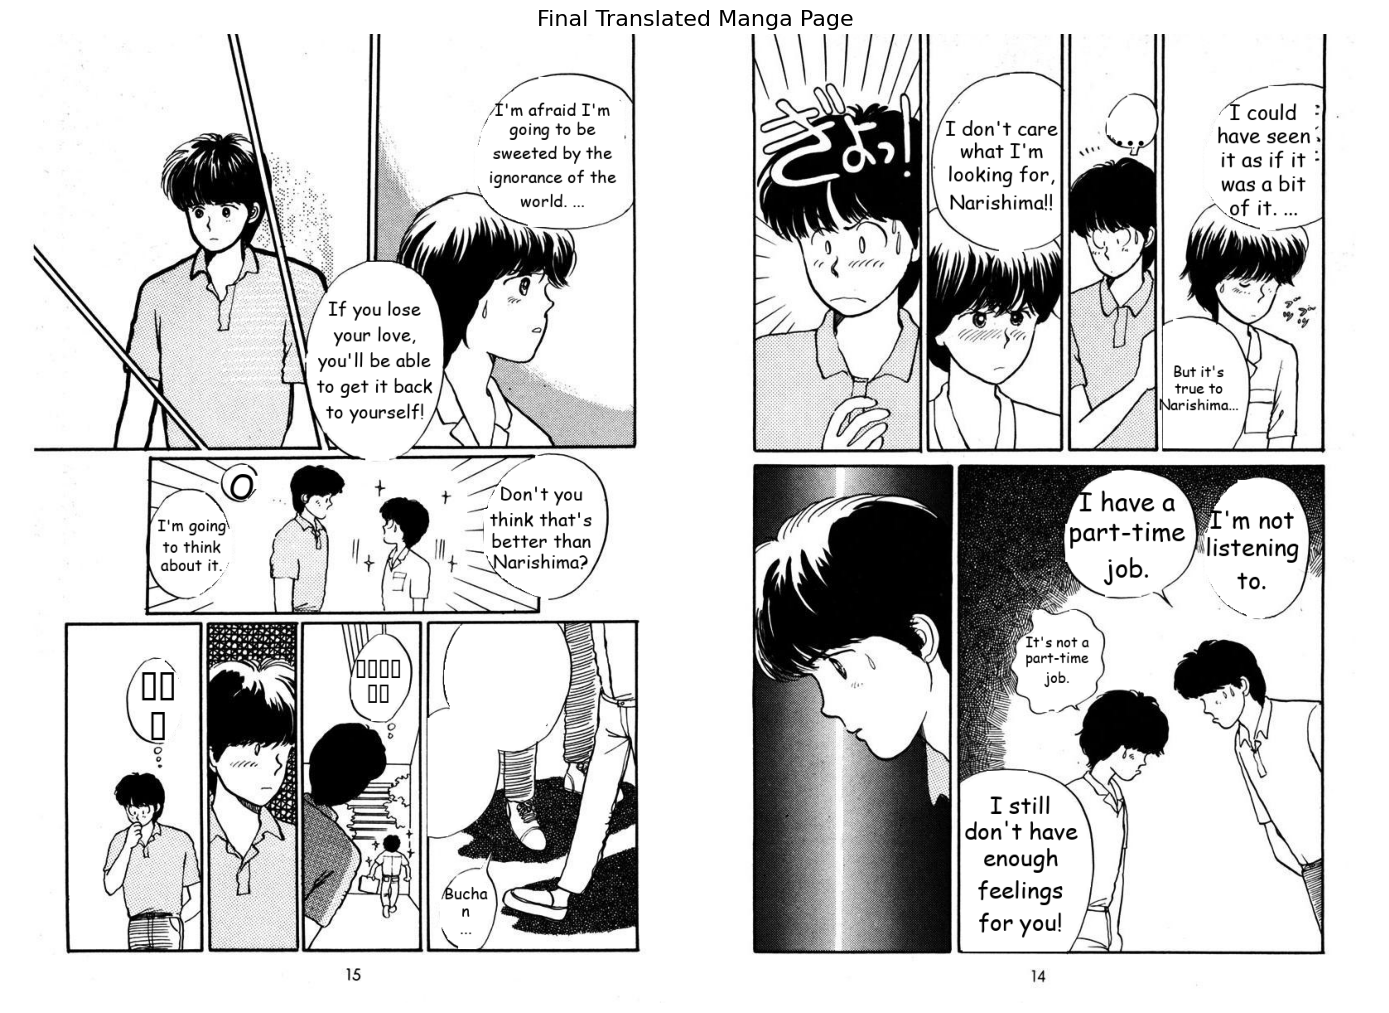

In [ ]:
# Display final result larger
plt.figure(figsize=(14, 18))
plt.imshow(final_image)
plt.title("Final Translated Manga Page", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


## Testing Complete!

The pipeline successfully:
1. Detects speech bubbles with YOLO segmentation
2. Orders bubbles in manga reading order (right-to-left, top-to-bottom)
3. Uses panel detection for better bubble grouping
4. Performs OCR on each bubble
5. Translates Japanese to English
6. Typesets translated text back onto the image
